In [15]:
%load_ext autoreload
%autoreload 2

# configure project root
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.oracle_env import PDPTWEnv
from src.oracle_policy import PDPTWAttentionPolicy
from src.oracle_generator import SFGenerator
from src.oracle_env_render import render
from src.or_tools import darp_solver as solver

import torch
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load and instantialize policy from checkpoint

In [23]:
ckpt_path_cloned = str(PROJECT_ROOT) + "/checkpoints/Feb_01_5_cloning/best.pt"
ckpt_path_rl = str(PROJECT_ROOT) + "/checkpoints/Jan1402/best.pt"
ckpt_path_refpol = str(PROJECT_ROOT) + "/checkpoints/Feb_01_6_finetune/latest.pt"

device = torch.device('cpu')

rl_policy = PDPTWAttentionPolicy().to(device)
cloned_policy = PDPTWAttentionPolicy().to(device)
refined_policy = PDPTWAttentionPolicy().to(device)

ckpt = torch.load(ckpt_path_cloned, map_location=device)
ckpt_rl = torch.load(ckpt_path_rl, map_location=device)
ckpt_refpol = torch.load(ckpt_path_refpol, map_location=device)

cloned_policy.load_state_dict(ckpt["policy_state_dict"])
cloned_policy.eval()

rl_policy.load_state_dict(ckpt_rl["policy_state_dict"])
rl_policy.eval()

refined_policy.load_state_dict(ckpt_refpol['policy_state_dict'])
refined_policy.eval()



PDPTWAttentionPolicy(
  (init_embedding): PDPTWInitEmbedding(
    (project): Linear(in_features=34, out_features=128, bias=True)
  )
  (encoder): GraphAttentionNetwork(
    (layers): ModuleList(
      (0-2): 3 x MultiHeadAttentionLayer(
        (attn): MultiHeadAttention(
          (Wqkv): Linear(in_features=128, out_features=384, bias=True)
          (out_proj): Linear(in_features=128, out_features=128, bias=True)
        )
        (norm1): Normalization(
          (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (ffn): MLP(
          (net): Sequential(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): ReLU()
            (2): Linear(in_features=512, out_features=128, bias=True)
          )
        )
        (norm2): Normalization(
          (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
  )
  (context_embedding): PDPTWContextE

Web Mercator basemap failed: The EPSG code is unknown. PROJ: internal_proj_create_from_database: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_create_from_database: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


actions shape for 16 environments: torch.Size([16, 70])
Route:  [[0, 45, 46, 31, 32, 3, 4, 55, 56, 25, 57, 58, 26, 7, 27, 8, 28, 11, 33, 34, 12, 17, 59, 60, 18, 9, 43, 10, 44, 23, 24, 53, 54, 1, 2, 51, 52, 19, 39, 40, 20, 0, 5, 21, 13, 37, 6, 22, 38, 14, 41, 42, 47, 49, 15, 16, 50, 48, 35, 36, 29, 30, 0]]


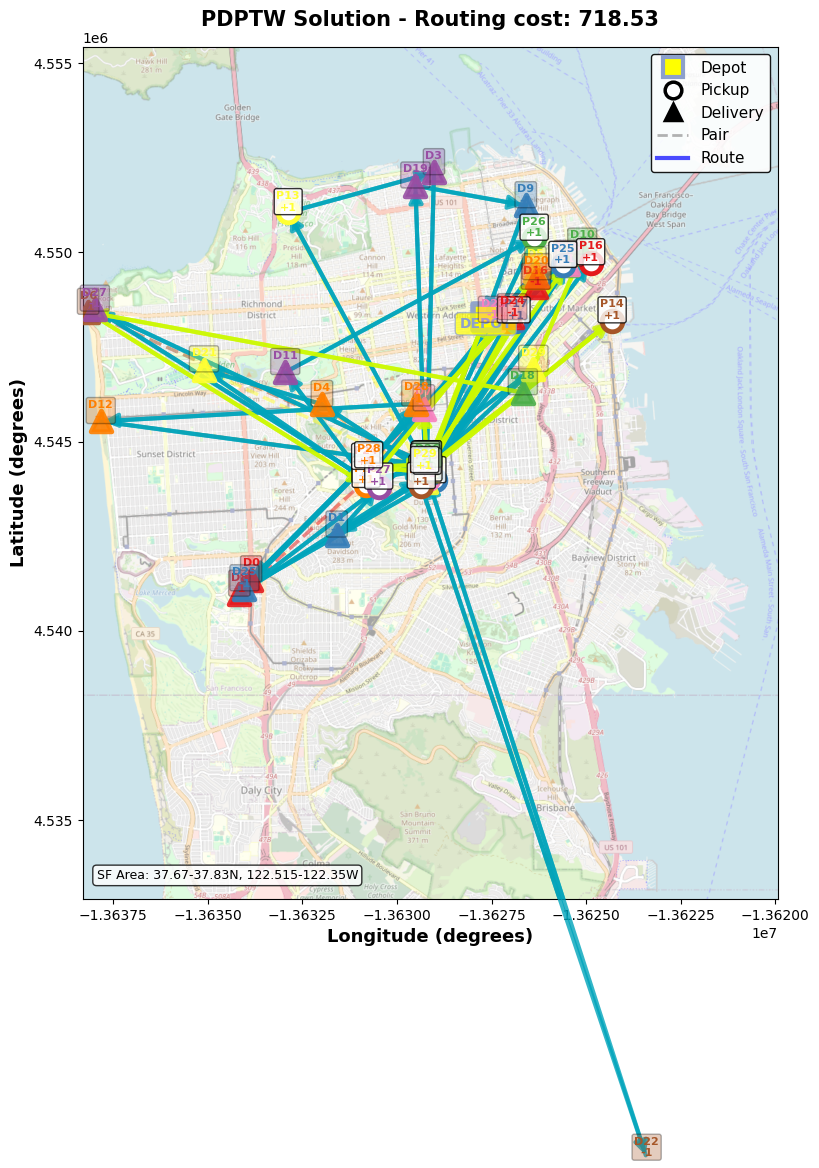

In [24]:
csv_path = Path(str(PROJECT_ROOT) + "/src/traveler_trip_types_res_7.csv")
ttm_path = Path(str(PROJECT_ROOT) + "/src/travel_time_matrix_res_7.csv")

generator = SFGenerator(csv_path=csv_path, travel_time_matrix_path=ttm_path)
env = PDPTWEnv(generator=generator)

batch_size = 16
batch = generator(batch_size=[batch_size]).to(device)
state = env.reset(batch)

with torch.inference_mode():
    out = cloned_policy(state, env, phase="test", decode_type="greedy", max_steps=300)

actions = out["actions"]
print(f"actions shape for {batch_size} environments: {actions.shape}")

batch = generator(batch_size=[1]).to(device)
state = env.reset(batch)

with torch.inference_mode():
    out = cloned_policy(state, env, phase="test", decode_type="greedy", max_steps=300)

actions = out["actions"]  # shape [1, seq_len]
reward = env.get_reward(batch, actions)
routing_cost = (-reward[0]).item()

effective_route = env._build_effective_routes(actions)
print("Route: ", effective_route)

# render
fig, ax = plt.subplots(figsize=(14, 12))
render(batch, actions=actions, ax=ax)
ax.set_title(f"PDPTW Solution - Routing cost: {routing_cost:.2f}", fontsize=15, weight="bold", pad=15)
plt.show()

# Performance comparison across methods

In [22]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

num_instances = 100
customer_counts = [10, 20, 30]
methods = ["RL", "Cloned", "Cloned+RL", "OR-Tools"]

# Store results: {num_customers: {method: [costs]}}
results = {n: {m: [] for m in methods} for n in customer_counts}

# Store batches for reuse
saved_batches = {n: [] for n in customer_counts}

# ============================================================
# PART 1: Generate environments and compute OR-Tools costs
# ============================================================
print("=" * 50)
print("PART 1: Generating instances and computing OR-Tools")
print("=" * 50)

for num_customers in customer_counts:
    print(f"\n=== {num_customers} customers ===")
    
    generator = SFGenerator(csv_path=csv_path, travel_time_matrix_path=ttm_path, num_customers=num_customers)
    env = PDPTWEnv(generator=generator)

    for _ in tqdm(range(num_instances), desc=f"OR-Tools {num_customers} customers"):
        batch = generator(batch_size=[1]).to(device)
        saved_batches[num_customers].append(batch)
        
        state_opt = env.reset(batch)
        or_out = solver(state_opt, time_limit_seconds=1, vehicle_cost=0)
        total_time = or_out.get("total_time", float("inf"))
        if not np.isfinite(total_time):
            total_time = np.nan
        results[num_customers]["OR-Tools"].append(total_time)

PART 1: Generating instances and computing OR-Tools

=== 10 customers ===


OR-Tools 10 customers: 100%|██████████| 100/100 [01:40<00:00,  1.00s/it]



=== 20 customers ===


OR-Tools 20 customers: 100%|██████████| 100/100 [01:40<00:00,  1.00s/it]



=== 30 customers ===


OR-Tools 30 customers: 100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


In [25]:
print("\n" + "=" * 50)
print("PART 2: Computing RL methods on saved instances")
print("=" * 50)

for num_customers in customer_counts:
    print(f"\n=== {num_customers} customers ===")
    
    generator = SFGenerator(csv_path=csv_path, travel_time_matrix_path=ttm_path, num_customers=num_customers)
    env = PDPTWEnv(generator=generator)

    for i, batch in enumerate(tqdm(saved_batches[num_customers], desc=f"RL methods {num_customers} customers")):
        state_clone = env.reset(batch)
        state_rl = env.reset(batch)
        state_refined = env.reset(batch)

        with torch.inference_mode():
            cloned_out = cloned_policy(state_clone, env, phase="test", decode_type="greedy", max_steps=300)
            rl_out = rl_policy(state_rl, env, phase="test", decode_type="greedy", max_steps=300)
            refined_out = refined_policy(state_refined, env, phase="test", decode_type="greedy", max_steps=300)

        cloned_reward = env.get_reward(batch, cloned_out["actions"])
        rl_reward = env.get_reward(batch, rl_out["actions"])
        refined_reward = env.get_reward(batch, refined_out["actions"])

        results[num_customers]["Cloned"].append((-cloned_reward[0]).item())
        results[num_customers]["RL"].append((-rl_reward[0]).item())
        results[num_customers]["Cloned+RL"].append((-refined_reward[0]).item())


PART 2: Computing RL methods on saved instances

=== 10 customers ===


RL methods 10 customers: 100%|██████████| 100/100 [00:07<00:00, 13.42it/s]



=== 20 customers ===


RL methods 20 customers: 100%|██████████| 100/100 [00:15<00:00,  6.46it/s]



=== 30 customers ===


RL methods 30 customers: 100%|██████████| 100/100 [00:24<00:00,  4.07it/s]


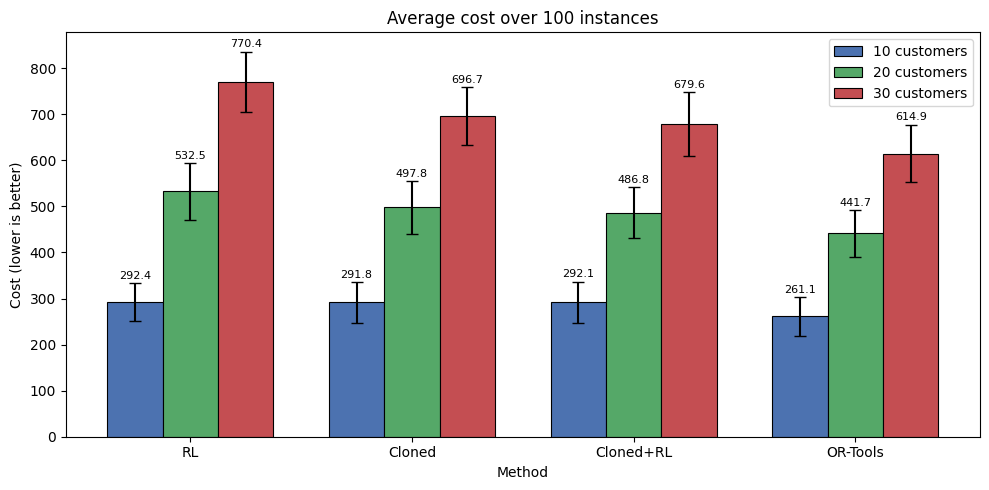

In [26]:
# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(methods))
width = 0.25
colors = ["#4C72B0", "#55A868", "#C44E52"]  # Blue, Green, Red

for i, num_customers in enumerate(customer_counts):
    means = [np.nanmean(results[num_customers][m]) for m in methods]
    stds = [np.nanstd(results[num_customers][m]) for m in methods]
    
    bars = ax.bar(x + i * width, means, width, yerr=stds, 
                  label=f"{num_customers} customers", color=colors[i], 
                  edgecolor="black", capsize=4, linewidth=0.8)
    
    # Add cost labels on top of bars
    for j, (bar, mean) in enumerate(zip(bars, means)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + stds[j] + 5,
                f"{mean:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Method")
ax.set_ylabel("Cost (lower is better)")
ax.set_title(f"Average cost over {num_instances} instances")
ax.set_xticks(x + width)
ax.set_xticklabels(methods)
ax.legend()
plt.tight_layout()
plt.show()


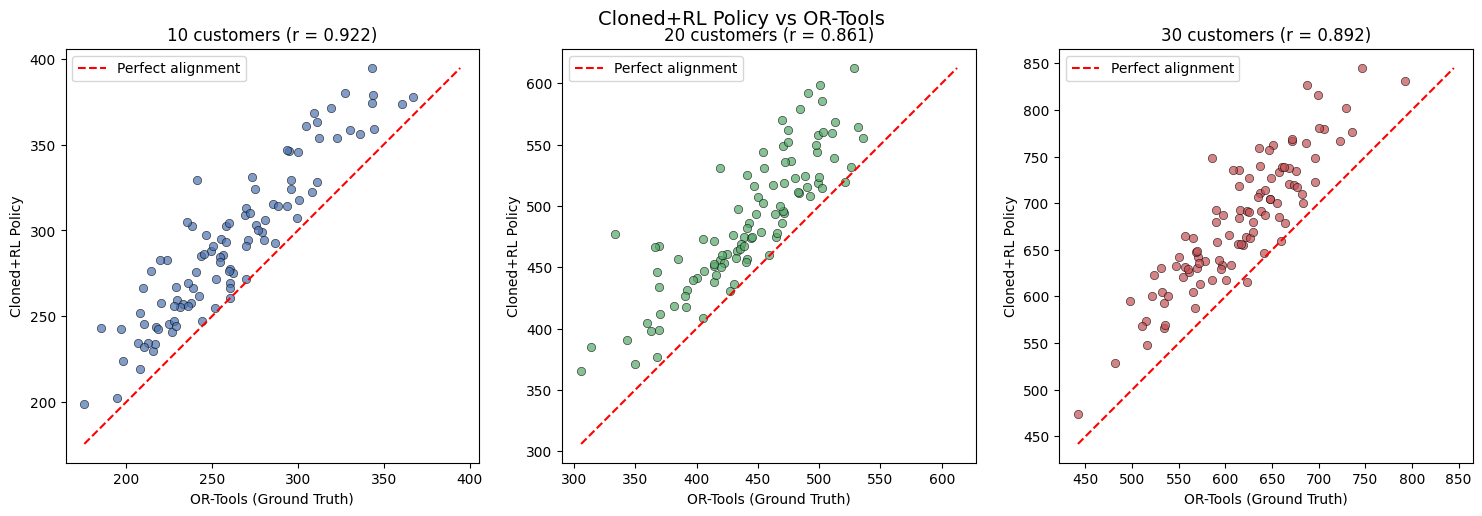

In [28]:
# Scatter plot using data from results dict
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]  # Blue, Green, Red

for i, num_customers in enumerate(customer_counts):
    ax = axes[i]
    
    refined_arr = np.array(results[num_customers]["Cloned+RL"], dtype=float)
    opt_arr = np.array(results[num_customers]["OR-Tools"], dtype=float)
    
    # Scatter plot
    ax.scatter(opt_arr, refined_arr, alpha=0.7, edgecolor="black", linewidth=0.5, color=colors[i])
    
    # Diagonal line (perfect alignment)
    mask = np.isfinite(opt_arr) & np.isfinite(refined_arr)
    min_val = min(np.nanmin(opt_arr[mask]), np.nanmin(refined_arr[mask]))
    max_val = max(np.nanmax(opt_arr[mask]), np.nanmax(refined_arr[mask]))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect alignment")
    
    # Correlation
    corr = np.corrcoef(opt_arr[mask], refined_arr[mask])[0, 1]
    
    ax.set_xlabel("OR-Tools (Ground Truth)")
    ax.set_ylabel("Cloned+RL Policy")
    ax.set_title(f"{num_customers} customers (r = {corr:.3f})")
    ax.legend()
    ax.set_aspect('equal')

plt.suptitle("Cloned+RL Policy vs OR-Tools", fontsize=14)
plt.tight_layout()
plt.show()